In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from ast import literal_eval
import warnings
import re

warnings.filterwarnings('ignore')

# Data Loading

In [3]:
df = pd.read_csv('../data/raw/iclr_articles.csv') 

print(f"\nDataset size: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\Columns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.info())


Dataset size: 55906 rows, 10 columns
\Columns: ['year', 'id', 'title', 'abstract', 'authors', 'author_ids', 'decision', 'scores', 'keywords', 'labels']

Data types:
year          int64
id              str
title           str
abstract        str
authors         str
author_ids      str
decision        str
scores          str
keywords        str
labels          str
dtype: object

First 5 rows:
   year         id                                              title  \
0  2017  B1-Hhnslg        Prototypical Networks for Few-shot Learning   
1  2017  B1-q5Pqxl  Machine Comprehension Using Match-LSTM and Ans...   
2  2017  B16Jem9xe             Learning in Implicit Generative Models   
3  2017  B16dGcqlx                    Third Person Imitation Learning   
4  2017  B184E5qee  Improving Neural Language Models with a Contin...   

                                            abstract  \
0  A recent approach to few-shot classification c...   
1  Machine comprehension of text is an important ...  

In [4]:
df = df[df['year'] < 2026].reset_index().copy()
old_cols = list(df.columns)

In [5]:
import re

def to_list(s: str):
    s = s.strip()
    if s.startswith('[') and s.endswith(']'):
        s = s[1:-1]

    pattern = r"'([^']*)'"
    matches = re.findall(pattern, s)

    if not matches:
        return []

    return matches

df['keywords'] = df['keywords'].apply(to_list)


In [7]:
# Calculate abstract stats
df['abstract_length'] = df['abstract'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['abstract_word_count'] = df['abstract'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

# Calculate title stats
df['title_length'] = df['title'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

# Calculate manual keyword stats
df['num_keywords'] = df['keywords'].apply(len)

In [8]:
df['decision'].unique()

<StringArray>
[                  'Reject',          'Accept (Poster)',
 'Invite to Workshop Track',            'Accept (Oral)',
                'Withdrawn',       'Accept (Spotlight)',
            'Accept (Talk)',            'Desk rejected',
           'Accept: poster',  'Accept: notable-top-25%',
   'Accept: notable-top-5%',          'Accept (poster)',
       'Accept (spotlight)',            'Accept (oral)']
Length: 14, dtype: str

In [9]:
# Create simplified decisions
def simplify_decision(d):
    if pd.isna(d):
        return 'Unknown'
    d_lower = str(d).lower()
    if 'accept' in d_lower and ('oral' in d_lower or 'spotlight' in d_lower):
        return 'Accept (Oral/Spotlight)'
    elif 'accept' in d_lower and 'poster' in d_lower:
        return 'Accept (Poster)'
    elif 'accept' in d_lower:
        return 'Accept'
    elif 'reject' in d_lower:
        return 'Reject'
    elif 'workshop' in d_lower:
        return 'Workshop'
    elif 'withdraw' in d_lower:
        return 'Withdrawn'
    else:
        return str(d)

df['decision_simplified'] = df['decision'].apply(simplify_decision)

# Binary classification: accepted / not accepted
df['is_accepted'] = df['decision_simplified'].apply(
    lambda x: 1 if 'Accept' in str(x) or 'Workshop' in str(x) else 0
)

In [10]:
print("New columns after preprocessing:")
new_cols = [c for c in df.columns if c not in old_cols]
print(new_cols)
print(f"\nNew feature stats:")
print(df[new_cols].describe().round(2))

New columns after preprocessing:
['abstract_length', 'abstract_word_count', 'title_length', 'title_word_count', 'num_keywords', 'decision_simplified', 'is_accepted']

New feature stats:
       abstract_length  abstract_word_count  title_length  title_word_count  \
count         36113.00             36113.00      36113.00          36113.00   
mean           1289.40               180.72         70.80              8.59   
std             319.98                45.12         20.71              2.73   
min             108.00                16.00          8.00              1.00   
25%            1070.00               150.00         57.00              7.00   
50%            1272.00               178.00         71.00              8.00   
75%            1489.00               208.00         83.00             10.00   
max            4999.00               719.00        179.00             25.00   

       num_keywords  is_accepted  
count      36113.00     36113.00  
mean           3.47         0.31

# Feature Analysis

In [11]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing values': missing,
    'missing pct (%)': missing_pct
})
missing_df = missing_df[missing_df['missing values'] > 0].sort_values('missing pct (%)', ascending=False)
print(missing_df if len(missing_df) > 0 else "No missing values!")

            missing values  missing pct (%)
author_ids            5663            15.68


## Year

This section analyses how the number of submitted and accepted papers has changed over the years.


Publication distribution by years:
year
2017      489
2018     1012
2019     1569
2020     2593
2021     3009
2022     3422
2023     4955
2024     7401
2025    11663
Name: count, dtype: int64


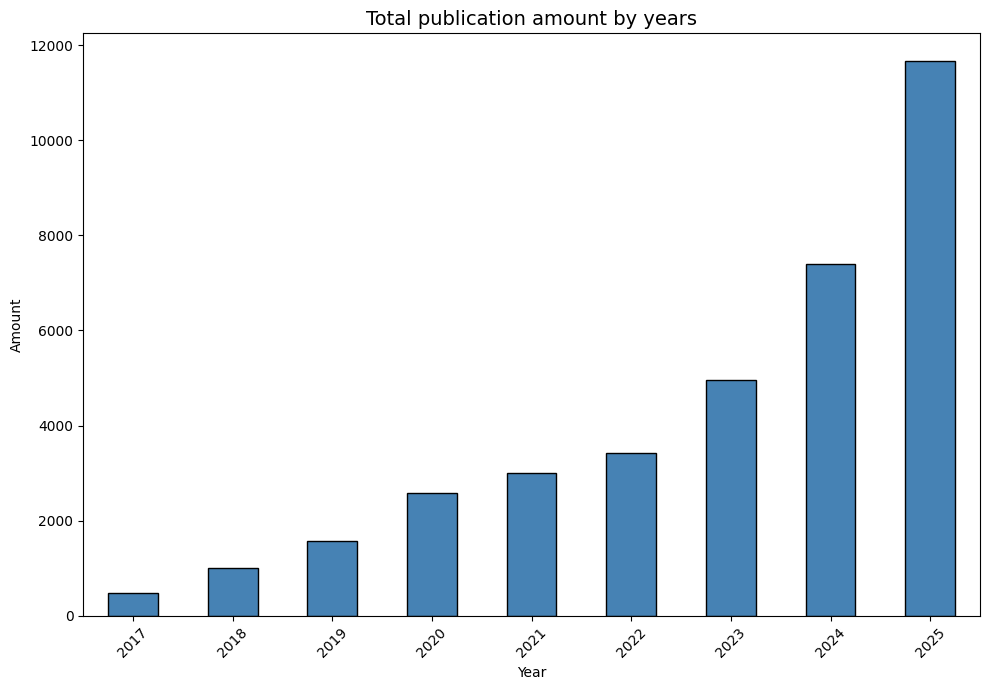

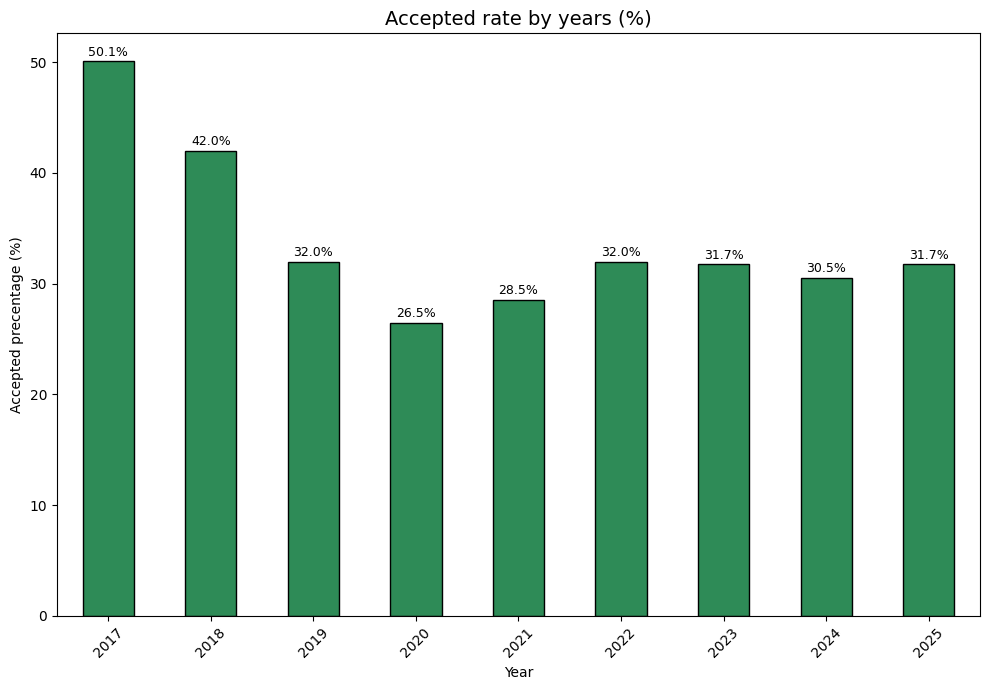

In [12]:
year_counts = df['year'].value_counts().sort_index()
print(f"\nPublication distribution by years:")
print(year_counts)

# Publication amount by years
fig, ax = plt.subplots(figsize=(10, 7))
year_counts.plot(kind='bar', color='steelblue', ax=ax, edgecolor='black')
ax.set_title('Total publication amount by years', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Amount')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/iclr_data_exploration/01_year_publication_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Accepted rate per year
fig, ax = plt.subplots(figsize=(10, 7))
acceptance_by_year = df.groupby('year')['is_accepted'].mean() * 100
acceptance_by_year.plot(kind='bar', color='seagreen', ax=ax, edgecolor='black')
ax.set_title('Accepted rate by years (%)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Accepted precentage (%)')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(acceptance_by_year):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/iclr_data_exploration/02_accepted_year_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Decision

This section shows how papers are distributed across different decision categories — accepted, rejected, withdrawn, and others. Understanding this distribution reveals the overall selectivity of ICLR and how different acceptance tracks (oral, spotlight, poster) compare in volume.

In [13]:
print("\nDecision distribution (original):")
print(df['decision'].value_counts())

print("\nDecision distribution (simplified):")
print(df['decision_simplified'].value_counts())


Decision distribution (original):
decision
Reject                      17096
Withdrawn                    7474
Accept (Poster)              6173
Accept (poster)              1809
Accept: poster               1202
Accept (Spotlight)            775
Accept (Oral)                 383
Accept (spotlight)            366
Accept: notable-top-25%       280
Desk rejected                 194
Invite to Workshop Track      136
Accept: notable-top-5%         91
Accept (oral)                  86
Accept (Talk)                  48
Name: count, dtype: int64

Decision distribution (simplified):
decision_simplified
Reject                     17290
Accept (Poster)             9184
Withdrawn                   7474
Accept (Oral/Spotlight)     1610
Accept                       419
Workshop                     136
Name: count, dtype: int64


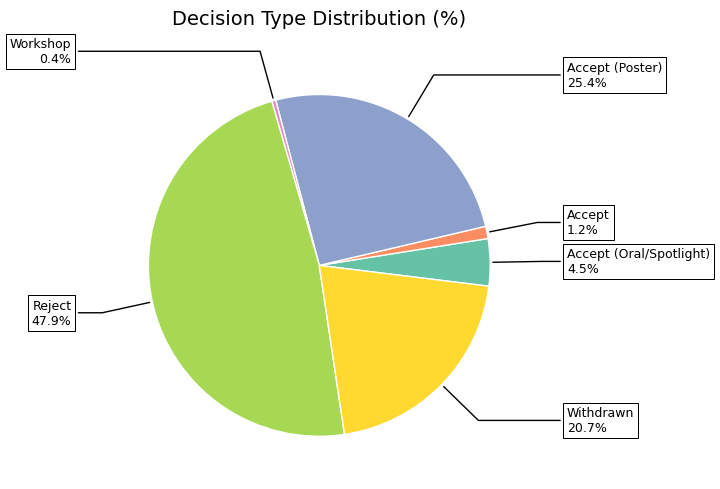

In [14]:
decision_counts = df['decision_simplified'].value_counts()
colors = sns.color_palette('Set2', len(decision_counts))
labels =  [
    'Accept (Oral/Spotlight)',
    'Accept',
    'Accept (Poster)',
    'Workshop',
    'Reject',
    'Withdrawn',
]
values = np.array([int(decision_counts[label]) for label in labels])
total = values.sum()

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(aspect="equal"))

wedges, _ = ax.pie(
    values,
    colors=colors,
    startangle=-7,
    wedgeprops=dict(edgecolor='white', linewidth=1),
)

bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"), bbox=bbox_props, zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1) / 2.0 + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    pct = values[i] / total * 100
    ax.annotate(
        f"{labels[i]}\n{pct:.1f}%",
        xy=(x, y),
        xytext=(1.45 * np.sign(x), 1.3 * y),
        horizontalalignment=horizontalalignment,
        fontsize=9,
        **kw,
    )

ax.set_title('Decision Type Distribution (%)', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('images/iclr_data_exploration/03_decisions_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Take only accepted papers
df = df[df['is_accepted'] == 1].reset_index().copy()
df.shape

(11349, 19)

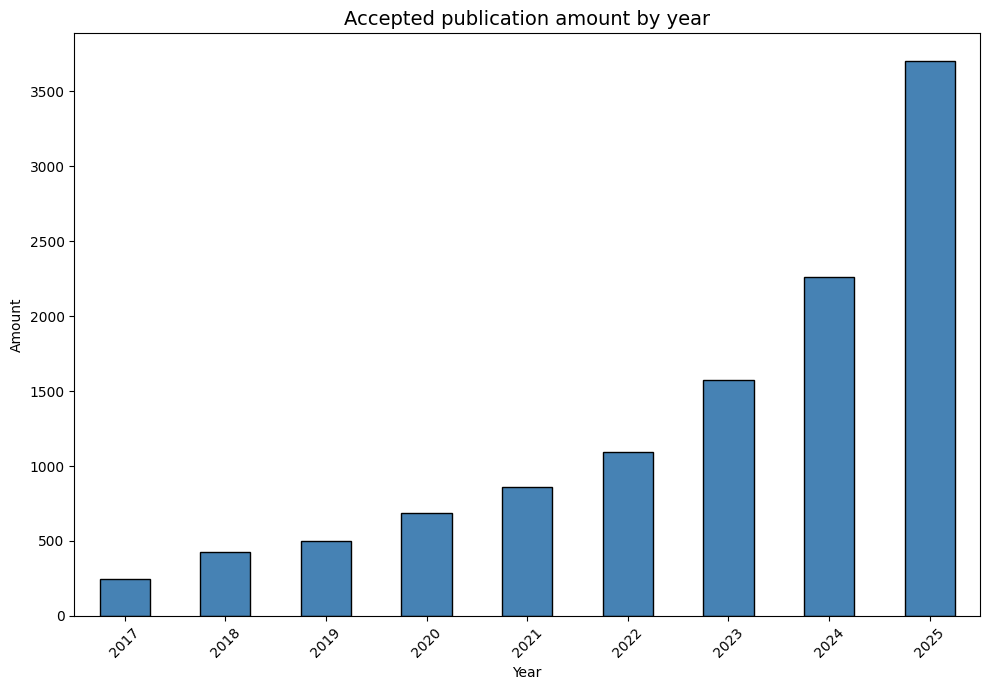

In [16]:
# Accepted publication distribution by year
fig, ax = plt.subplots(figsize=(10, 7))

acceptance_counts = df['year'].value_counts().sort_index()

acceptance_counts.plot(kind='bar', color='steelblue', ax=ax, edgecolor='black')
ax.set_title('Accepted publication amount by year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Amount')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/iclr_data_exploration/04_accepted_publication_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Keywords and Labels

This section explores the keywords of accepted papers. By looking at the most frequent author-provided keywords and assigned topic labels, we can identify which research areas dominate the conference and how topic popularity is distributed.


Total unique keywords: 15050

Top 30 keywords:
   1. 'reinforcement learning': 703
   2. 'deep learning': 696
   3. 'large language models': 454
   4. 'representation learning': 361
   5. 'graph neural networks': 259
   6. 'diffusion models': 259
   7. 'generative models': 218
   8. 'large language model': 217
   9. 'self-supervised learning': 205
  10. 'optimization': 200
  11. 'interpretability': 189
  12. 'generalization': 186
  13. 'natural language processing': 177
  14. 'transformer': 174
  15. 'unsupervised learning': 168
  16. 'robustness': 160
  17. 'computer vision': 151
  18. 'diffusion model': 150
  19. 'federated learning': 146
  20. 'transformers': 140
  21. 'transfer learning': 139
  22. 'contrastive learning': 138
  23. 'neural networks': 134
  24. 'benchmark': 134
  25. 'language models': 130
  26. 'llm': 125
  27. 'deep reinforcement learning': 121
  28. 'continual learning': 112
  29. 'adversarial robustness': 106
  30. 'meta-learning': 104


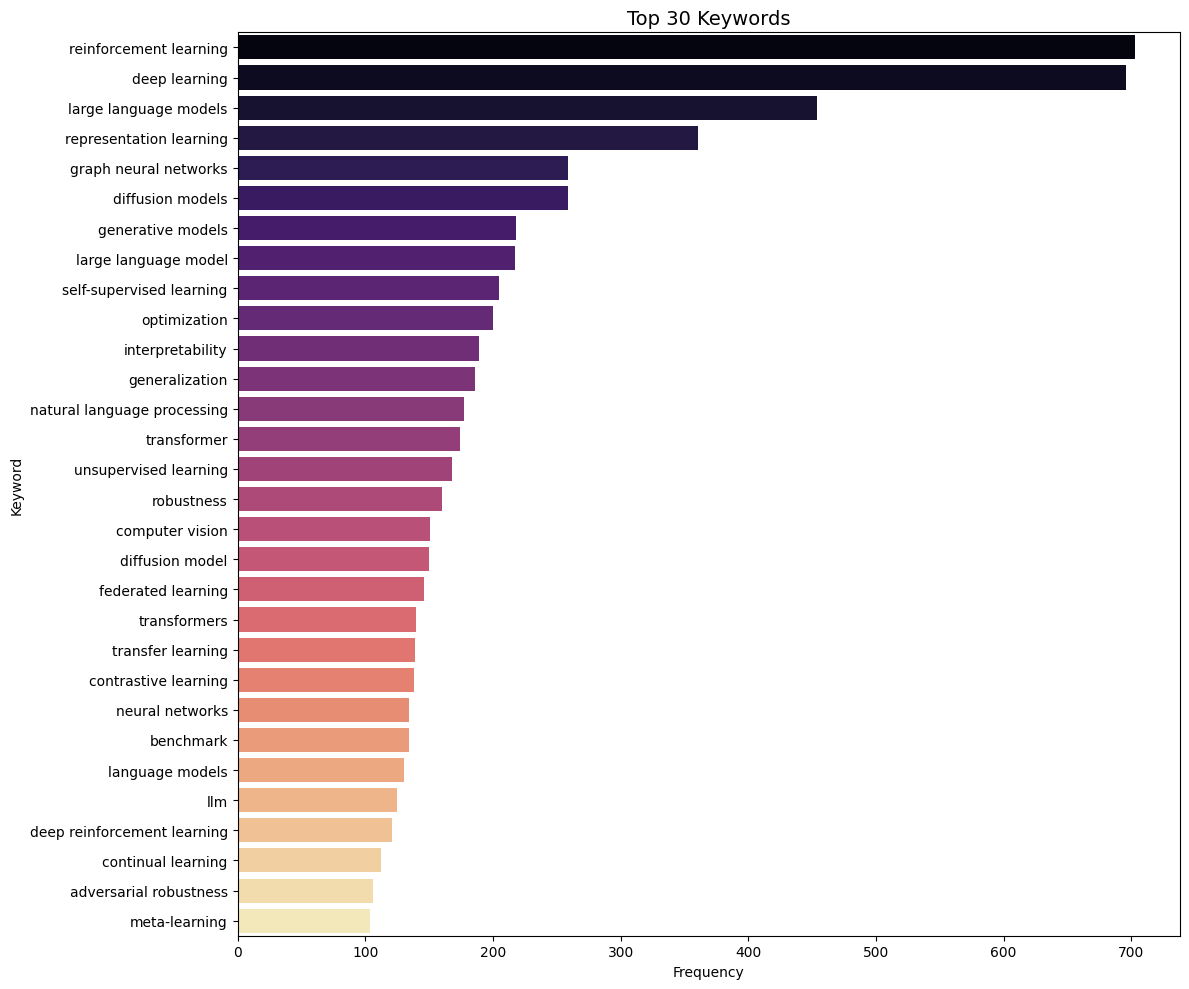

In [17]:
all_keywords = [kw.strip().lower() for kws in df['keywords'] for kw in kws if isinstance(kw, str)]
keyword_counter = Counter(all_keywords)
top_keywords = keyword_counter.most_common(30)

print(f"\nTotal unique keywords: {len(keyword_counter)}")
print(f"\nTop 30 keywords:")
for i, (kw, cnt) in enumerate(top_keywords, 1):
    print(f"  {i:2d}. '{kw}': {cnt}")

fig, ax = plt.subplots(figsize=(12, 10))
kw_df = pd.DataFrame(top_keywords, columns=['Keyword', 'Frequency'])
sns.barplot(data=kw_df, y='Keyword', x='Frequency', palette='magma', ax=ax)
ax.set_title('Top 30 Keywords', fontsize=14)
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('images/iclr_data_exploration/05_top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print(f"Number of unique labels:")
print(df['labels'].nunique())

print(f"\nUnique labels:")
print(df['labels'].value_counts()[:15])

Number of unique labels:
51

Unique labels:
labels
unlabeled                   5080
LLMs                         594
RL                           499
language models              418
diffusion models             382
optimization                 369
graphs                       322
adversarial                  283
transformers                 242
self-supervised learning     221
transfer learning            144
GANs                         128
continual learning           112
meta learning                110
RNNs                         109
Name: count, dtype: int64


## Title and Abstract

This section analyses the length of paper titles and abstracts in terms of word count.


Abstract length statistics (words):
count    11349.00
mean       181.43
std         43.55
min         37.00
25%        152.00
50%        179.00
75%        208.00
max        468.00
Name: abstract_word_count, dtype: float64

Title length statistics (words):
count    11349.00
mean         8.49
std          2.67
min          1.00
25%          7.00
50%          8.00
75%         10.00
max         23.00
Name: title_word_count, dtype: float64


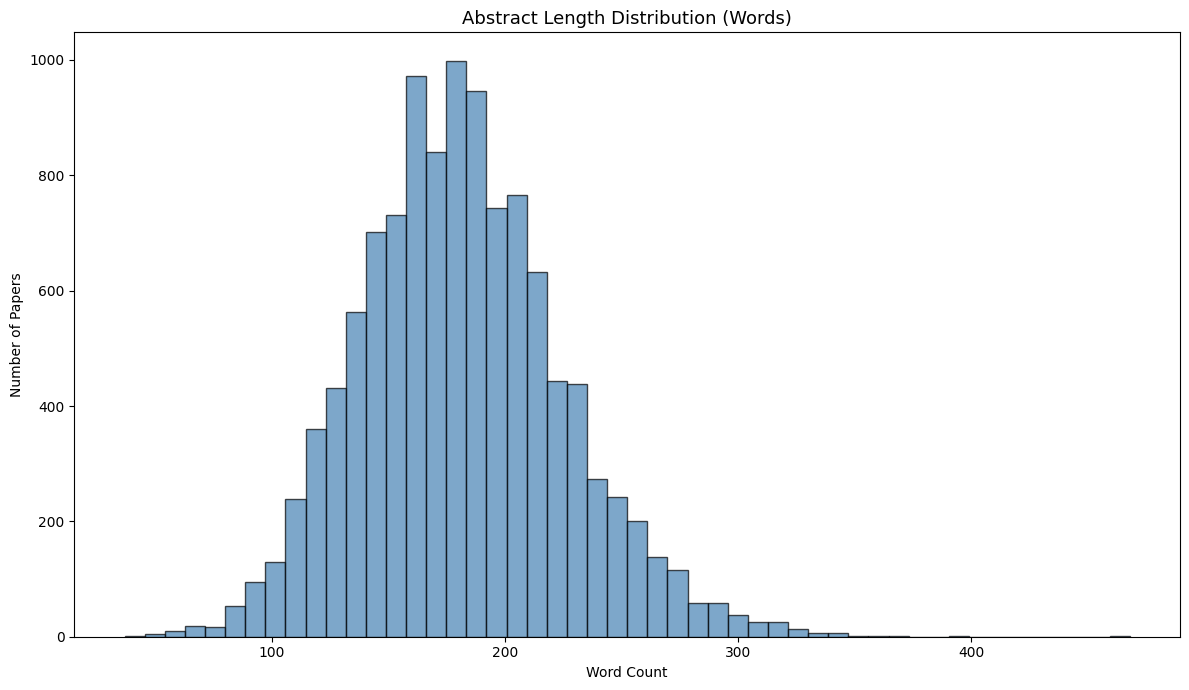

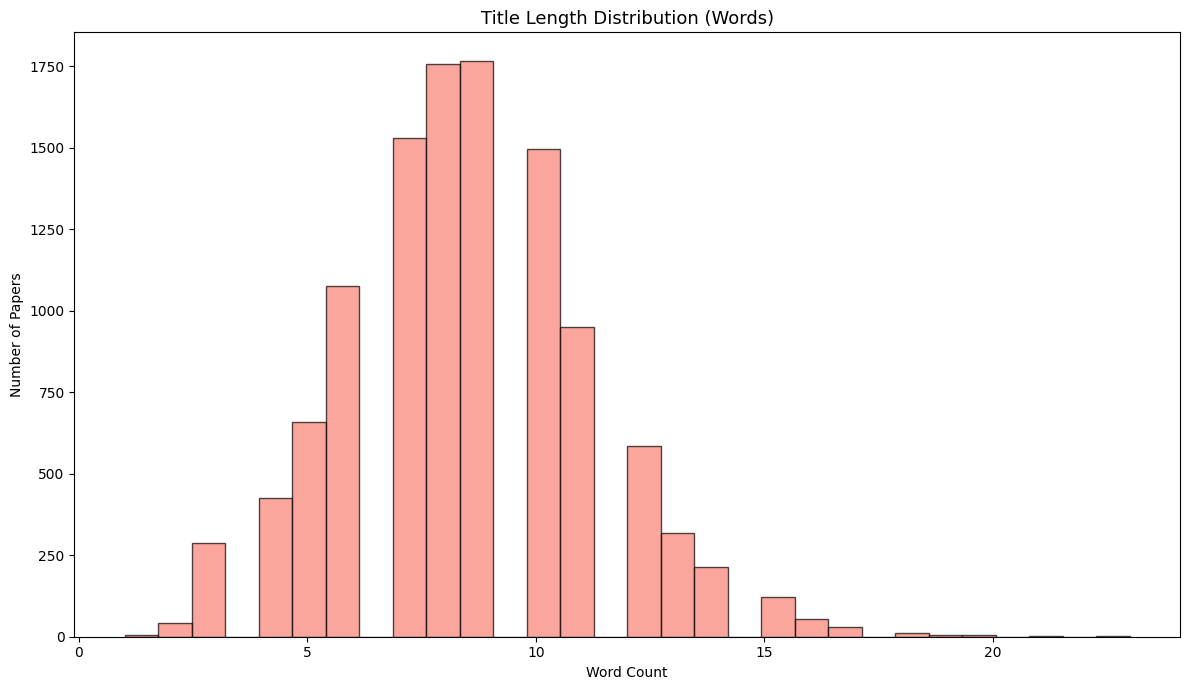

In [19]:
print(f"\nAbstract length statistics (words):")
print(df['abstract_word_count'].describe().round(2))

print(f"\nTitle length statistics (words):")
print(df['title_word_count'].describe().round(2))

# Abstract length distribution
fig, ax = plt.subplots(figsize=(12, 7))
ax.hist(df['abstract_word_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Abstract Length Distribution (Words)', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Papers')

plt.tight_layout()
plt.savefig('images/iclr_data_exploration/06_abstract_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Title length distribution
fig, ax = plt.subplots(figsize=(12, 7))
ax.hist(df['title_word_count'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
ax.set_title('Title Length Distribution (Words)', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Papers')

plt.tight_layout()
plt.savefig('images/iclr_data_exploration/07_title_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Year and Label Heatmap

To understand how research trends in ICLR have changed over the years, article labels can be compared with the year of publication. The first heatmap shows the total number of articles with a given label published in each year. The second shows the percentage share of each label in that year, making it easier to identify topics whose popularity is increasing or decreasing, independent of the overall growth in incoming articles.

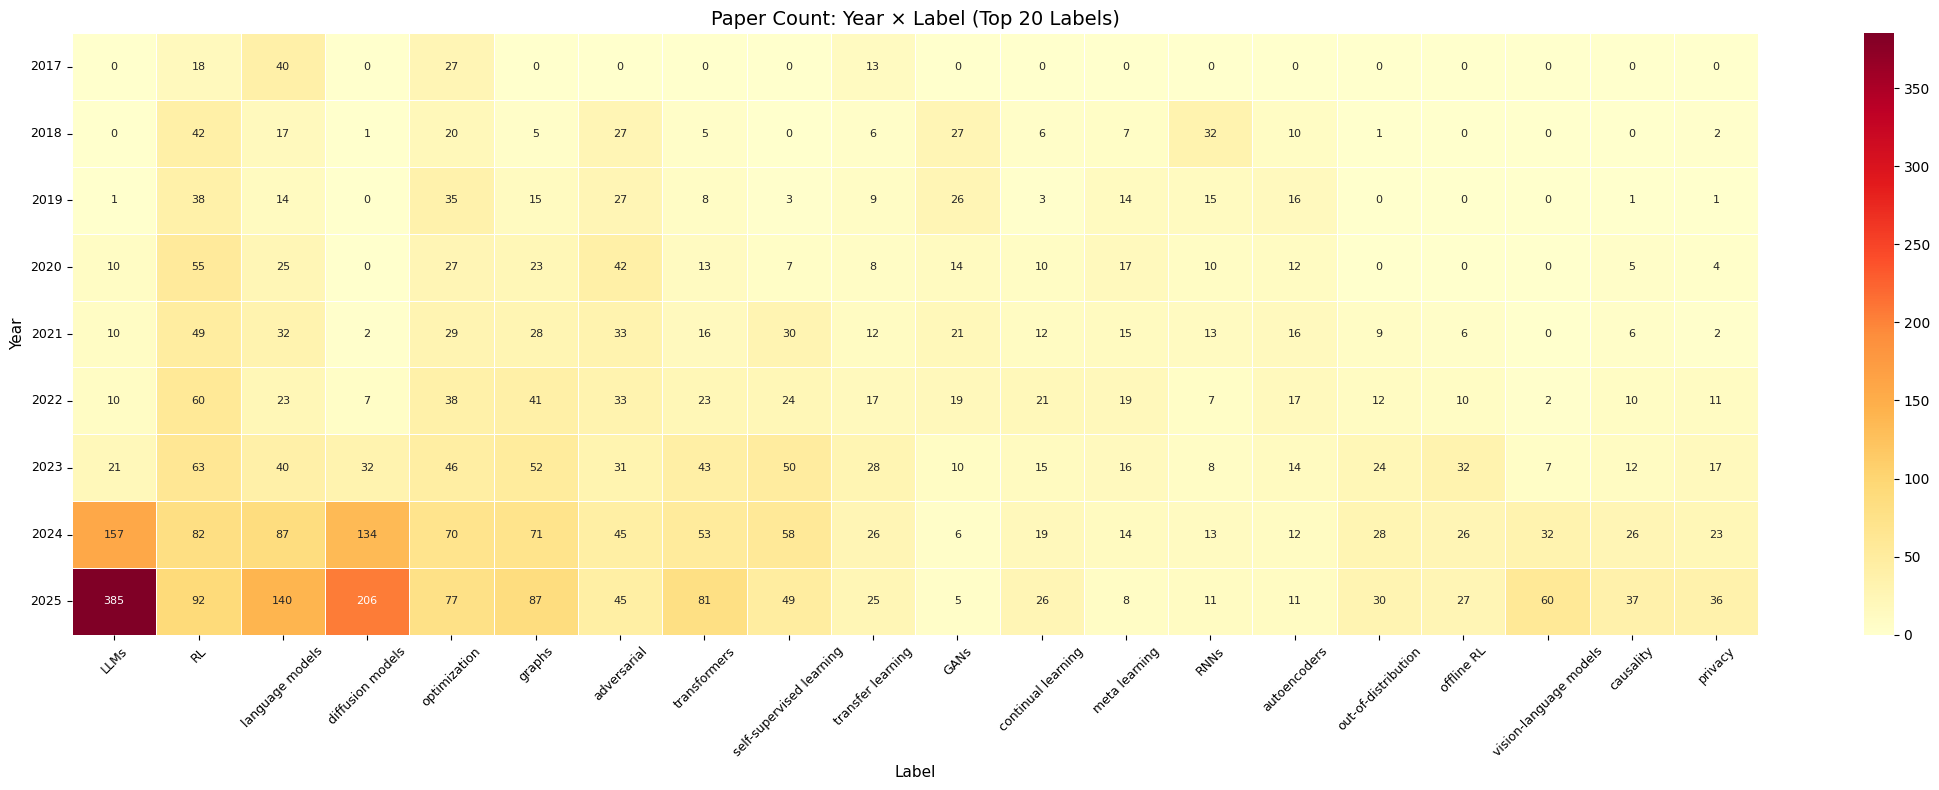

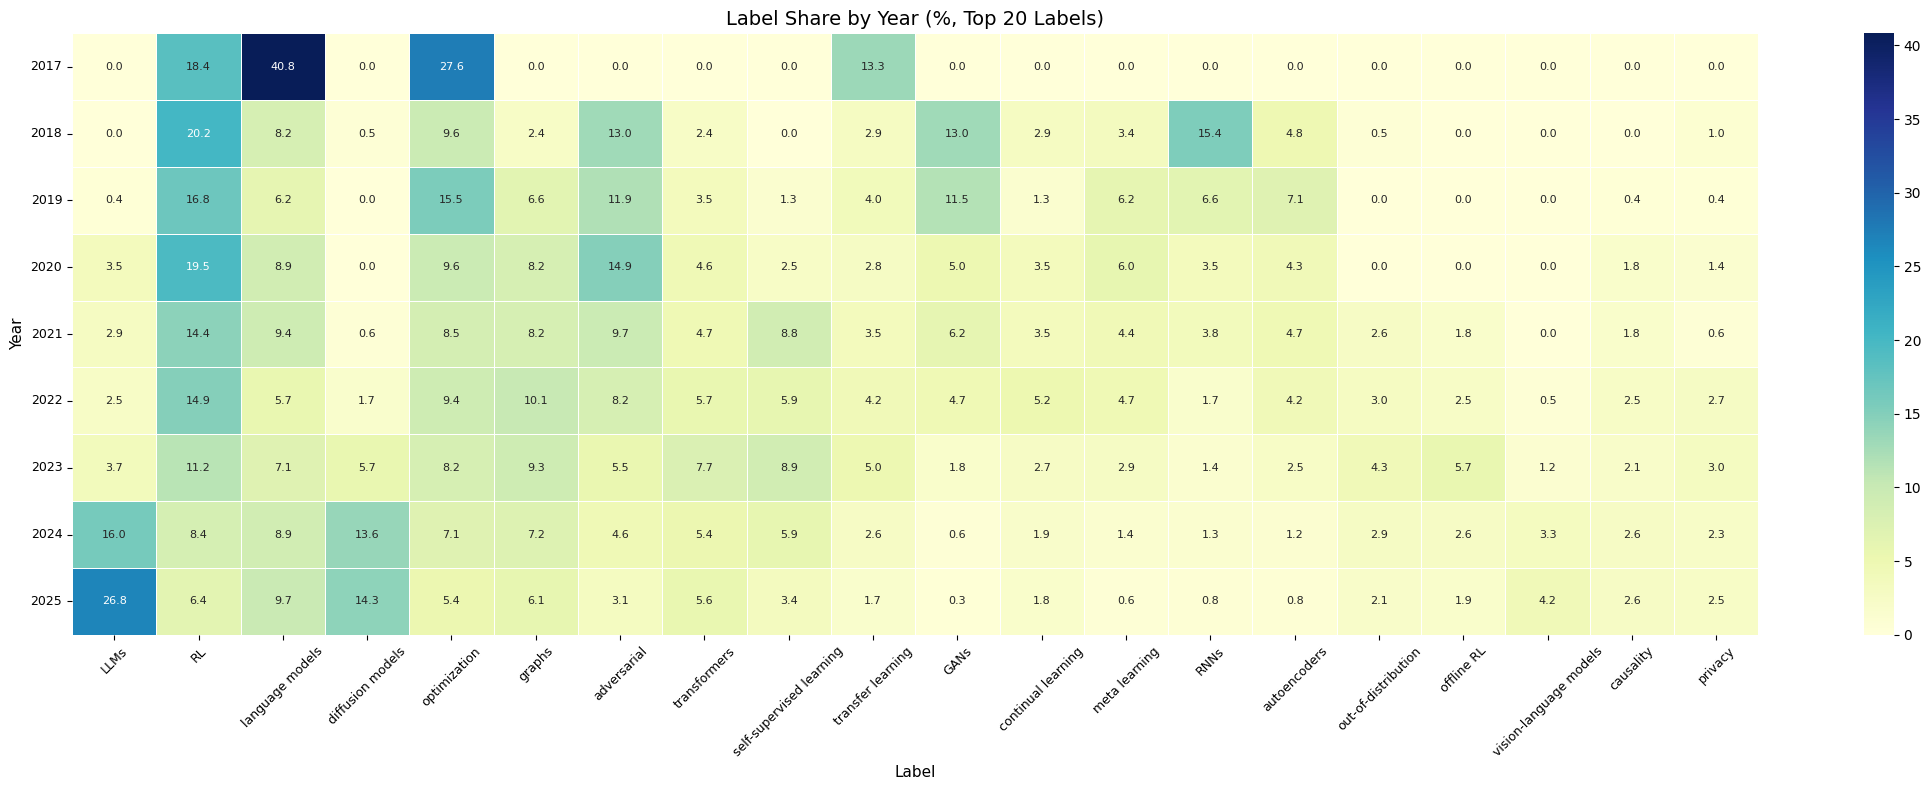

In [20]:
# Keep only top 20 labels without unlabeled by total count to avoid overcrowding
top_labels = df[df['labels'] != 'unlabeled']['labels'].value_counts().head(20).index
df_top = df[df['labels'].isin(top_labels)]

cross_year_label = pd.crosstab(df_top['year'], df_top['labels'])
# Reorder columns by total frequency
col_order = df_top['labels'].value_counts().index
cross_year_label = cross_year_label.reindex(columns=col_order)

# Plot raw counts
fig, ax = plt.subplots(figsize=(22, 8))
sns.heatmap(
    cross_year_label,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.4,
    annot_kws={'size': 8},
)
ax.set_title('Paper Count: Year × Label (Top 20 Labels)', fontsize=14)
ax.set_xlabel('Label', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('images/iclr_data_exploration/08_year_label_heatmap_counts.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot row-normalised (% share within each year)
cross_norm = cross_year_label.div(cross_year_label.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(22, 8))
sns.heatmap(
    cross_norm,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    ax=ax,
    linewidths=0.4,
    annot_kws={'size': 8},
)
ax.set_title('Label Share by Year (%, Top 20 Labels)', fontsize=14)
ax.set_xlabel('Label', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('images/iclr_data_exploration/09_year_label_heatmap_pct.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusion

This EDA of ICLR submissions from 2017 to 2025 reveals several patterns in the dataset.

**Volume and acceptance.** The number of submissions has grown substantially over the years. Despite this growth, the overall acceptance rate has remained relatively stable, hovering around 25–32%, which points to a consistently competitive review process.

**Decision distribution.** The majority of reviewed papers are rejected. Among accepted papers, poster presentations dominate, while oral and spotlight tracks account for a much smaller share — consistent with the tiered recognition system ICLR uses to highlight the strongest contributions.

**Research topics.** The papers accepted for publication are largely organized around a few themes. Deep learning, reinforcement learning, and natural language processing have been a constant presence in the history of data science. Recently, terms such as LLMs, diffusion models, and transformers have seen a sharp increase in usage, directly reflecting a broader shift in the field toward large-scale generative models.

**Temporal trends.** The year–label heatmap makes it clear that the thematic composition of accepted papers has changed over time. Topics like GANs and RNNs were relatively more popular in earlier years, while LLMs and diffusion models are almost exclusively a phenomenon of 2022 and beyond. This aligns well with the known history of deep learning research.

**Writing conventions.** Abstracts concentrate tightly around 150–200 words, and titles typically run 8–10 words. These distributions are narrow and consistent, suggesting well-established community norms around how papers are written and presented.